# Methods Notebook: Extracting Call Samples for KMeans Clustering

## Imports Section:

In [25]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [26]:
import librosa
import warnings

In [27]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [29]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer

## Function Definitions (most important functions are in `src/`)
### Below are the functions used for plotting and visualization

In [30]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}

In [31]:
file_sites = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}
bd2_dets_save_dir = Path(f'20241231__group_threshold_sweep_results')
raventxt_human_files_dir = f'{Path.home()}/Documents/mila-human-wav-txt'
extension = ".txt"
sep = "\t"

SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

file_keys = list(file_sites.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [32]:
def return_confusion_matrix_from_comparing_two_detectors(human_df, machine_df):
    false_positives = 0 ## machine made detection that human did not make
    true_positives = 0  ## machine made detection that human made
    true_negatives = 0  ## machine did not make detection that human also did not make
    false_negatives = 0 ## machine did not make detection that human made
    human_ind = 0
    machine_ind = 0

    while (human_ind < len(human_df))&(machine_ind < len(machine_df)):
        human_det = human_df.iloc[human_ind]
        machine_det = machine_df.iloc[machine_ind]

        machine_det_start_in_human_det_bounds = ((machine_det['start_time']>=human_det['start_time'])&(machine_det['start_time']<=human_det['end_time']))
        machine_det_end_in_human_det_bounds = ((machine_det['end_time']>=human_det['start_time'])&(machine_det['end_time']<=human_det['end_time']))
        human_det_start_in_machine_det_bounds = ((human_det['start_time']>=machine_det['start_time'])&(human_det['start_time']<=machine_det['end_time']))
        human_det_end_in_machine_det_bounds = ((human_det['end_time']>=machine_det['start_time'])&(human_det['end_time']<=machine_det['end_time']))
        machine_det_time_in_human_bounds = machine_det_start_in_human_det_bounds|machine_det_end_in_human_det_bounds
        human_det_time_in_machine_bounds = human_det_start_in_machine_det_bounds|human_det_end_in_machine_det_bounds

        machine_det_low_in_human_det_bounds = ((machine_det['low_freq']>=human_det['low_freq'])&(machine_det['low_freq']<=human_det['high_freq']))
        machine_det_high_in_human_det_bounds = ((machine_det['high_freq']>=human_det['low_freq'])&(machine_det['high_freq']<=human_det['high_freq']))
        human_det_low_in_machine_det_bounds = ((human_det['low_freq']>=machine_det['low_freq'])&(human_det['low_freq']<=machine_det['high_freq']))
        human_det_high_in_machine_det_bounds = ((human_det['high_freq']>=machine_det['low_freq'])&(human_det['high_freq']<=machine_det['high_freq']))
        machine_det_freq_in_human_bounds = machine_det_low_in_human_det_bounds|machine_det_high_in_human_det_bounds
        human_det_freq_in_machine_bounds = human_det_low_in_machine_det_bounds|human_det_high_in_machine_det_bounds

        machine_det_time_matches_human_time = (machine_det_time_in_human_bounds|human_det_time_in_machine_bounds)
        machine_det_freq_matches_human_time = (machine_det_freq_in_human_bounds|human_det_freq_in_machine_bounds)
        machine_detection_corresponds_to_human = machine_det_time_matches_human_time&machine_det_freq_matches_human_time

        if len(human_df) < 100:
            print(f'HI:{human_ind}, MI:{machine_ind}, TP:{true_positives}, FP:{false_positives}, FN:{false_negatives}, TN:{true_negatives}')
            print(f'Dets match time: {machine_det_time_matches_human_time}, Dets match freq: {machine_det_freq_matches_human_time}')

        if (machine_detection_corresponds_to_human):
            true_positives += 1
            machine_ind+=1
            human_ind+=1
        else:
            ## Machine detection is referring to call not detected by human (thus, it detected a non-bat call)
            false_positive_same_group_before_human_det = (machine_det['end_time']<=human_det['start_time'])&(machine_det_freq_matches_human_time)
            false_positive_diff_group_before_human_det = (machine_det['start_time']<=human_det['start_time'])&(~machine_det_freq_matches_human_time)

            false_negative_same_group_before_human_det = (machine_det['start_time']>human_det['end_time'])&(machine_det_freq_matches_human_time)
            false_negative_diff_group_before_human_det = (machine_det['start_time']>human_det['start_time'])&(~machine_det_freq_matches_human_time)

            if len(human_df) < 100:
                print(f'FP same group: {false_positive_same_group_before_human_det}, FP diff group: {false_positive_diff_group_before_human_det}')
                print(f'FN same group: {false_negative_same_group_before_human_det}, FN diff group: {false_negative_diff_group_before_human_det}')
            if (false_positive_same_group_before_human_det|false_positive_diff_group_before_human_det):
                false_positives += 1
                machine_ind+=1
            ## Machine has skipped a human-annotated call in detection (thus, it did not detect a bat call)
            elif (false_negative_same_group_before_human_det|false_negative_diff_group_before_human_det):
                false_negatives += 1
                human_ind+=1
            else:
                true_negatives += 1

    if (machine_ind<len(machine_df)):
        false_positives += (len(machine_df) - (machine_ind))
    if (human_ind<len(human_df)):
        false_negatives += (len(human_df) - (human_ind))

    assert((true_positives+false_negatives)==len(human_df))
    assert((false_positives+true_positives)==len(machine_df))

    return {'true_positives':true_positives, 'false_positives':false_positives, 'false_negatives':false_negatives, 'true_negatives':true_negatives}

## Following the confusion matrix structure shown below

![image](example_confusion_matrix.png)

In [33]:
def gather_evaluation_results_between_bd2_and_human(bd2_human_df, batdetect2_df_thresh):
    file_batdetect2_cf = return_confusion_matrix_from_comparing_two_detectors(bd2_human_df, batdetect2_df_thresh)
    row = pd.DataFrame([file_batdetect2_cf])
    row.insert(0, 'num_human_annotations', [len(bd2_human_df)])
    row.insert(0, 'num_bd2_detections', [len(batdetect2_df_thresh)])
    denom_precision = (file_batdetect2_cf['true_positives'] + file_batdetect2_cf['false_positives'])
    denom_recall = (file_batdetect2_cf['true_positives'] + file_batdetect2_cf['false_negatives'])
    if (denom_precision>0):
        precision = file_batdetect2_cf['true_positives'] / denom_precision
    else:
        precision = np.NaN
    if (denom_recall>0):
        recall = file_batdetect2_cf['true_positives'] / denom_recall
    else:
        recall = np.NaN
    row['precision'] = precision
    row['recall'] = recall

    return row

In [34]:
batdetect2_eval = pd.read_csv(bd2_dets_save_dir / '20241231__bd2_eval_results_per_thresh_and_file.csv', index_col=0)
batdetect2_eval_LF = pd.read_csv(bd2_dets_save_dir / '20241231__bd2_LFeval_results_per_thresh_and_file.csv', index_col=0)
batdetect2_eval_HF = pd.read_csv(bd2_dets_save_dir / '20241231__bd2_HFeval_results_per_thresh_and_file.csv', index_col=0)

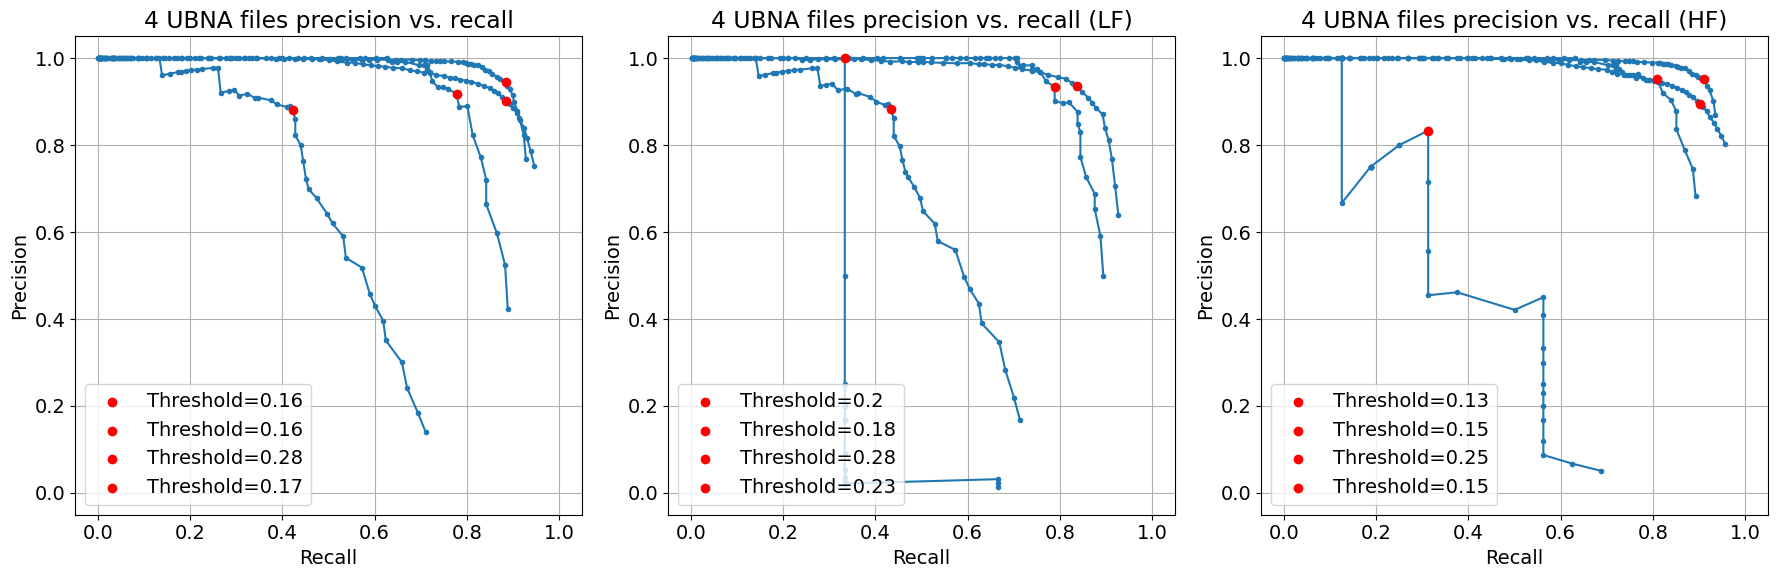

In [35]:
fig, (ax1, ax2, ax3), = plt.subplots(1, 3, figsize=(18,6))
plt.rcParams.update({'font.size':14})
ax1.set_title(f'4 UBNA files precision vs. recall')
precisions_per_thresh = batdetect2_eval['precision']
recalls_per_thresh = batdetect2_eval['recall']
thresholds = batdetect2_eval['detection_threshold']
ax1.plot(recalls_per_thresh, precisions_per_thresh, marker='.')
for file in batdetect2_eval['input_file_name'].unique():
    batdetect2_eval_file = batdetect2_eval[batdetect2_eval['input_file_name']==file].copy()
    file_precisions = batdetect2_eval_file['precision']
    file_recalls = batdetect2_eval_file['recall']
    common_max = (file_precisions * file_recalls).argmax()
    ax1.scatter(file_recalls.iloc[common_max], file_precisions.iloc[common_max], color='r', label=f'Threshold={round(thresholds[common_max], 3)}', zorder=2)
ax1.grid(which='both')
ax1.set_xlim(-0.05,1.05)
ax1.set_ylim(-0.05,1.05)
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.legend(loc='lower left')

ax2.set_title(f'4 UBNA files precision vs. recall (LF)')
precisions_per_thresh = batdetect2_eval_LF['precision']
recalls_per_thresh = batdetect2_eval_LF['recall']
ax2.plot(recalls_per_thresh, precisions_per_thresh, marker='.')
for file in batdetect2_eval_LF['input_file_name'].unique():
    batdetect2_eval_file = batdetect2_eval_LF[batdetect2_eval_LF['input_file_name']==file].copy()
    file_precisions = batdetect2_eval_file['precision']
    file_recalls = batdetect2_eval_file['recall']
    common_max = (file_precisions * file_recalls).argmax()
    ax2.scatter(file_recalls.iloc[common_max], file_precisions.iloc[common_max], color='r', label=f'Threshold={round(thresholds[common_max], 3)}', zorder=2)
ax2.grid(which='both')
ax2.set_xlim(-0.05,1.05)
ax2.set_ylim(-0.05,1.05)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='lower left')

ax3.set_title(f'4 UBNA files precision vs. recall (HF)')
precisions_per_thresh = batdetect2_eval_HF['precision']
recalls_per_thresh = batdetect2_eval_HF['recall']
ax3.plot(recalls_per_thresh, precisions_per_thresh, marker='.')
for file in batdetect2_eval_HF['input_file_name'].unique():
    batdetect2_eval_file = batdetect2_eval_HF[batdetect2_eval_HF['input_file_name']==file].copy()
    file_precisions = batdetect2_eval_file['precision']
    file_recalls = batdetect2_eval_file['recall']
    common_max = (file_precisions * file_recalls).argmax()
    ax3.scatter(file_recalls.iloc[common_max], file_precisions.iloc[common_max], color='r', label=f'Threshold={round(thresholds[common_max], 3)}', zorder=2)
ax3.grid(which='both')
ax3.set_xlim(-0.05,1.05)
ax3.set_ylim(-0.05,1.05)
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.legend(loc='lower left')

fig.tight_layout()
plt.show()